# 🏭 RECYCLE NET - SISTEMA INTELIGENTE DE CLASIFICACIÓN DE RESIDUOS

## Objetivo

Desarrollar un sistema de clasificación automática de residuos urbanos usando redes neuronales convolucionales y visión por computadora.

Se trabaja con un dataset compuesto por 9 categorías: vidrio, papel, cartón, plástico, metal, basura general, batería, biológico y textil.

## Pipeline

1. **Carga y organización** del dataset unificado desde dos fuentes de Kaggle.
2. **Análisis de balance** de clases con gráficos y estadísticas.
3. **Particionado estratificado** en train / validación / test.
4. **Segmentación semántica** con DeepLabV3 para aislar el objeto principal.
5. **Preprocesamiento y data augmentation** con transforms diferenciadas por split.
6. **Verificación final** del pipeline con visualización de batches.

---
## Librerías y Configuración Reproducible

In [1]:
import os
import random
import shutil

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
import torchvision.transforms as T

from torchvision.models.segmentation import deeplabv3_resnet50

from sklearn.model_selection import train_test_split

import cv2
import kagglehub

In [2]:
# Fijamos la semilla global para garantizar reproducibilidad en
# particionado, augmentations aleatorias y cualquier operación estocástica.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seed fijada: {SEED}")
print(f"Dispositivo: {DEVICE}")

Seed fijada: 42
Dispositivo: cuda


---
## a) Carga y Organización del Dataset

Se combinan dos datasets públicos de Kaggle para ampliar la diversidad y cantidad de clases:

| Dataset | Fuente Kaggle | Clases originales |
|---|---|---|
| `dataset_base` | `zlatan599/garbage-dataset-classification` | glass, paper, cardboard, plastic, metal |
| `dataset_industrial` | `mostafaabla/garbage-classification` | 12 subcategorías (brown-glass, clothes, battery, etc.) |

Ambos se mapean a 9 clases unificadas. La clase `trash` del primer data set se descarta porque en el segundo data set tiene más subdividida estas imágenes.

### Estructura de carpetas
```
dataset_root/
└── <clase>/
    ├── img001.jpg
    ├── img002.jpg
    └── ...
```
Cada subcarpeta representa una clase. Se recorre con `os.walk` para recolectar rutas e índices de etiqueta.

### Clase Dataset
Se implementa una clase `UnifiedGarbageDataset` que hereda de `torch.utils.data.Dataset`. En esta etapa devuelve la imagen como objeto PIL sin transformaciones, lo que permite reutilizarla para análisis exploratorio, segmentación y posterior wrapping con transforms.

In [4]:
print("📦 Descargando Dataset 1 (Base)...")
path_ds1 = kagglehub.dataset_download("zlatan599/garbage-dataset-classification")

print("📦 Descargando Dataset 2 (Industrial)...")
path_ds2 = kagglehub.dataset_download("mostafaabla/garbage-classification")

print("\n✅ Descargas completadas.")
print(f"📍 Ruta Dataset 1: {path_ds1}")
print(f"📍 Ruta Dataset 2: {path_ds2}")

📦 Descargando Dataset 1 (Base)...


100%|██████████| 121M/121M [00:08<00:00, 15.1MB/s]

Extracting files...


📦 Descargando Dataset 2 (Industrial)...


100%|██████████| 239M/239M [00:13<00:00, 18.4MB/s]

Extracting files...



✅ Descargas completadas.
📍 Ruta Dataset 1: /root/.cache/kagglehub/datasets/zlatan599/garbage-dataset-classification/versions/5
📍 Ruta Dataset 2: /root/.cache/kagglehub/datasets/mostafaabla/garbage-classification/versions/1


In [5]:
# Diccionario de clases objetivo con su índice numérico
TARGET_CLASSES = {
    "glass":      0,
    "paper":      1,
    "cardboard":  2,
    "plastic":    3,
    "metal":      4,
    "trash":      5,
    "battery":    6,
    "biological": 7,
    "textile":    8
}

# Diccionario inverso para visualizaciones
IDX_TO_CLASS = {
    0: "Vidrio",
    1: "Papel",
    2: "Cartón",
    3: "Plástico",
    4: "Metal",
    5: "Basura General",
    6: "Batería",
    7: "Biológico",
    8: "Textil"
}

# Configuración de mapeo por dataset fuente
DATASETS_CONFIG = [
    {
        "name": "dataset_base",
        "path": path_ds1,
        "mapping": {
            "glass":     "glass",
            "paper":     "paper",
            "cardboard": "cardboard",
            "plastic":   "plastic",
            "metal":     "metal",
            "trash":     None       # descartado por ambigüedad
        }
    },
    {
        "name": "dataset_industrial",
        "path": path_ds2,
        "mapping": {
            "brown-glass":  "glass",
            "green-glass":  "glass",
            "white-glass":  "glass",
            "paper":        "paper",
            "cardboard":    "cardboard",
            "plastic":      "plastic",
            "metal":        "metal",
            "battery":      "battery",
            "biological":   "biological",
            "clothes":      "textile",
            "shoes":        "textile",
            "unknown":      None,     # descartado
            "food-waste":   None      # descartado
        }
    }
]

print(f"Clases objetivo: {list(TARGET_CLASSES.keys())}")

Clases objetivo: ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash', 'battery', 'biological', 'textile']


In [6]:
class UnifiedGarbageDataset(Dataset):
    """
    Dataset unificado que combina múltiples fuentes con mapeo de clases.
    Devuelve imágenes PIL sin transformar para permitir flexibilidad
    en exploración, segmentación y wrapping posterior con transforms.
    """

    def __init__(self, datasets_config):
        self.samples = []  # lista de (ruta_imagen, label_int)
        for ds_cfg in datasets_config:
            self._load_dataset(ds_cfg)

    def _load_dataset(self, ds_cfg):
        dataset_path = ds_cfg["path"]
        mapping = ds_cfg["mapping"]

        for root, dirs, files in os.walk(dataset_path):
            class_name = os.path.basename(root).lower()

            if class_name not in mapping:
                continue

            target_class = mapping[class_name]

            if target_class is None:  # clase explícitamente ignorada
                continue

            target_label = TARGET_CLASSES[target_class]

            for file in files:
                if file.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.samples.append(
                        (os.path.join(root, file), target_label)
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("RGB")
        return image, label


full_dataset = UnifiedGarbageDataset(DATASETS_CONFIG)
print(f"✅ Dataset unificado: {len(full_dataset)} imágenes totales")

✅ Dataset unificado: 26219 imágenes totales


---
## Análisis de Balance del Dataset

Antes de particionar, analizamos la distribución de clases para:
- Detectar desbalance que pueda sesgar el entrenamiento.
- Justificar el uso de particionado **estratificado**.
- Decidir si se necesitan técnicas adicionales como oversampling o class weights.

In [7]:
# Conteo de muestras por clase
all_labels = [label for _, label in full_dataset.samples]
label_counts = pd.Series(all_labels).value_counts().sort_index()

class_names  = [IDX_TO_CLASS[i] for i in label_counts.index]
counts       = label_counts.values
total        = counts.sum()
percentages  = counts / total * 100

# DataFrame resumen
df_balance = pd.DataFrame({
    "Clase":      class_names,
    "Índice":     label_counts.index,
    "Cantidad":   counts,
    "Porcentaje": percentages.round(2)
})
print("=== Distribución del dataset completo ===")
print(df_balance.to_string(index=False))
print(f"\nTotal imágenes: {total}")
print(f"Clase más frecuente: {class_names[counts.argmax()]} ({counts.max()} imgs)")
print(f"Clase menos frecuente: {class_names[counts.argmin()]} ({counts.min()} imgs)")
print(f"Ratio max/min: {counts.max()/counts.min():.1f}x")

=== Distribución del dataset completo ===
    Clase  Índice  Cantidad  Porcentaje
   Vidrio       0      4511       17.21
    Papel       1      3365       12.83
   Cartón       2      3105       11.84
 Plástico       3      3153       12.03
    Metal       4      2853       10.88
  Batería       6       945        3.60
Biológico       7       985        3.76
   Textil       8      7302       27.85

Total imágenes: 26219
Clase más frecuente: Textil (7302 imgs)
Clase menos frecuente: Batería (945 imgs)
Ratio max/min: 7.7x


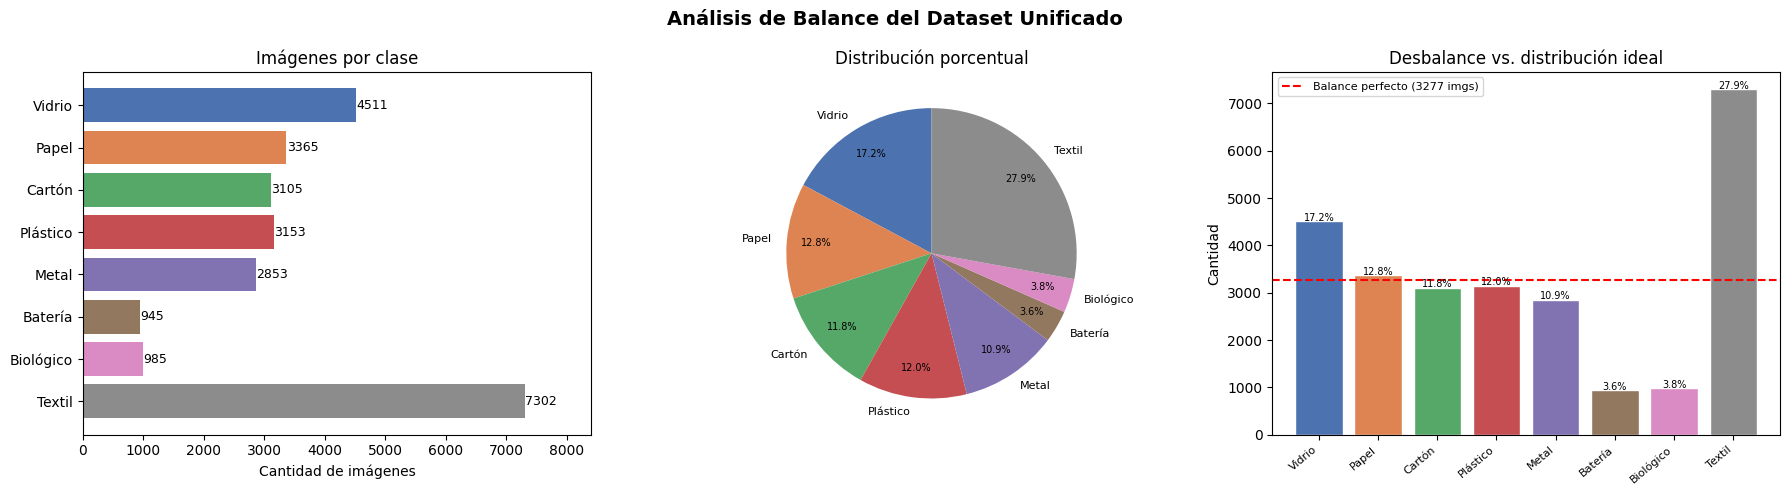


📊 El dataset presenta desbalance moderado-alto.
   → El particionado estratificado preservará las proporciones en cada split.


In [8]:
COLORS = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2",
    "#937860", "#DA8BC3", "#8C8C8C", "#CCB974"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Análisis de Balance del Dataset Unificado", fontsize=14, fontweight="bold")

# --- Gráfico 1: Barras horizontales con cantidad ---
ax = axes[0]
bars = ax.barh(class_names, counts, color=COLORS)
ax.set_xlabel("Cantidad de imágenes")
ax.set_title("Imágenes por clase")
ax.invert_yaxis()
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{count}", va="center", fontsize=9)
ax.set_xlim(0, counts.max() * 1.15)

# --- Gráfico 2: Pie chart con porcentajes ---
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    counts,
    labels=class_names,
    autopct="%1.1f%%",
    colors=COLORS,
    startangle=90,
    pctdistance=0.8
)
for text in texts:
    text.set_fontsize(8)
for autotext in autotexts:
    autotext.set_fontsize(7)
ax.set_title("Distribución porcentual")

# --- Gráfico 3: Barras verticales con línea de balance perfecto ---
ax = axes[2]
x = range(len(class_names))
bars2 = ax.bar(x, counts, color=COLORS, edgecolor="white")
ax.axhline(y=total/len(class_names), color="red", linestyle="--",
           linewidth=1.5, label=f"Balance perfecto ({int(total/len(class_names))} imgs)")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Cantidad")
ax.set_title("Desbalance vs. distribución ideal")
ax.legend(fontsize=8)
for bar, pct in zip(bars2, percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{pct:.1f}%", ha="center", fontsize=7)

plt.tight_layout()
plt.show()

print("\n📊 El dataset presenta desbalance moderado-alto.")
print("   → El particionado estratificado preservará las proporciones en cada split.")

---
## Exploración Visual del Dataset

Muestreo aleatorio de imágenes para verificar diversidad visual: variabilidad en iluminación, orientación, fondo y tamaño de los objetos.

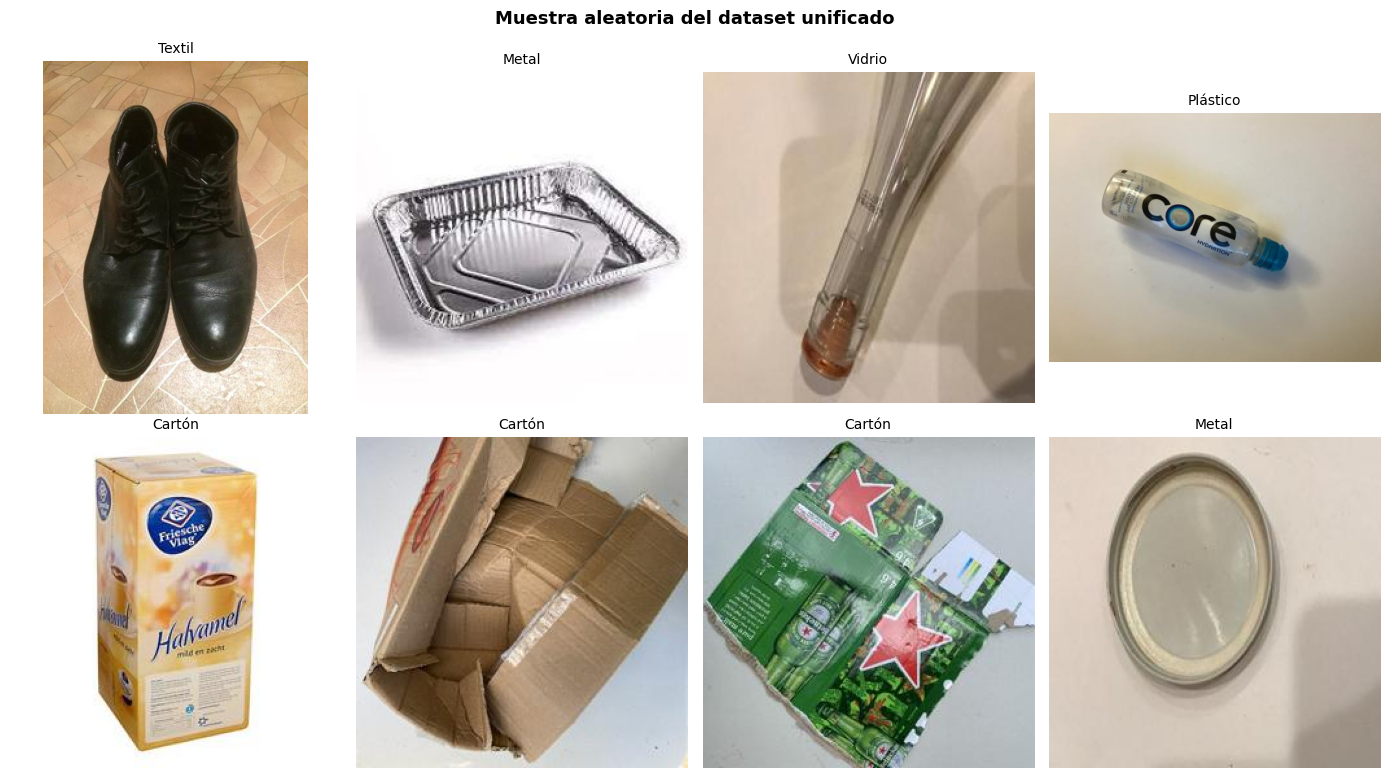

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
fig.suptitle("Muestra aleatoria del dataset unificado", fontsize=13, fontweight="bold")

for ax in axes.flatten():
    idx = random.randint(0, len(full_dataset) - 1)
    image, label = full_dataset[idx]
    ax.imshow(image)
    ax.set_title(IDX_TO_CLASS[label], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

---
## b) Particionado del Dataset

### Criterio
Se usa **particionado estratificado** (`stratify=labels`) para garantizar que cada split mantenga la misma distribución de clases que el dataset completo. Esto es fundamental dado el desbalance observado: sin estratificación, las clases minoritarias podrían estar subrepresentadas o ausentes en validación/test.

### Proporciones
- **Train**: 80 % del total
- **Validación**: 10 % del total
- **Test**: 10 % del total

Se fija `random_state=SEED` en ambas divisiones para reproducibilidad total.

In [10]:
indexes = list(range(len(full_dataset)))
labels  = [full_dataset[i][1] for i in indexes]

# Primera división: train (80%) vs temp (20%)
train_idx, temp_idx = train_test_split(
    indexes,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

# Segunda división: val (10%) vs test (10%) — mitad del temp
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED
)

print("=== Distribución de splits ===")
print(f"  Train:      {len(train_idx):>5} imágenes  ({len(train_idx)/len(indexes)*100:.1f}%)")
print(f"  Validación: {len(val_idx):>5} imágenes  ({len(val_idx)/len(indexes)*100:.1f}%)")
print(f"  Test:       {len(test_idx):>5} imágenes  ({len(test_idx)/len(indexes)*100:.1f}%)")
print(f"  Total:      {len(indexes):>5} imágenes")

=== Distribución de splits ===
  Train:      20975 imágenes  (80.0%)
  Validación:  2622 imágenes  (10.0%)
  Test:        2622 imágenes  (10.0%)
  Total:      26219 imágenes


In [11]:
# Distribución por clase en cada split
def count_by_class(idx_list, all_labels):
    counts = {i: 0 for i in range(len(TARGET_CLASSES))}
    for i in idx_list:
        counts[all_labels[i]] += 1
    return counts

train_counts = count_by_class(train_idx, labels)
val_counts   = count_by_class(val_idx,   labels)
test_counts  = count_by_class(test_idx,  labels)

df_splits = pd.DataFrame({
    "Clase":      [IDX_TO_CLASS[i] for i in range(len(TARGET_CLASSES))],
    "Train":      [train_counts[i] for i in range(len(TARGET_CLASSES))],
    "Validación": [val_counts[i]   for i in range(len(TARGET_CLASSES))],
    "Test":       [test_counts[i]  for i in range(len(TARGET_CLASSES))]
})

print("=== Imágenes por clase y split ===")
print(df_splits.to_string(index=False))

=== Imágenes por clase y split ===
         Clase  Train  Validación  Test
        Vidrio   3609         451   451
         Papel   2692         336   337
        Cartón   2484         311   310
      Plástico   2522         316   315
         Metal   2282         285   286
Basura General      0           0     0
       Batería    756          95    94
     Biológico    788          98    99
        Textil   5842         730   730


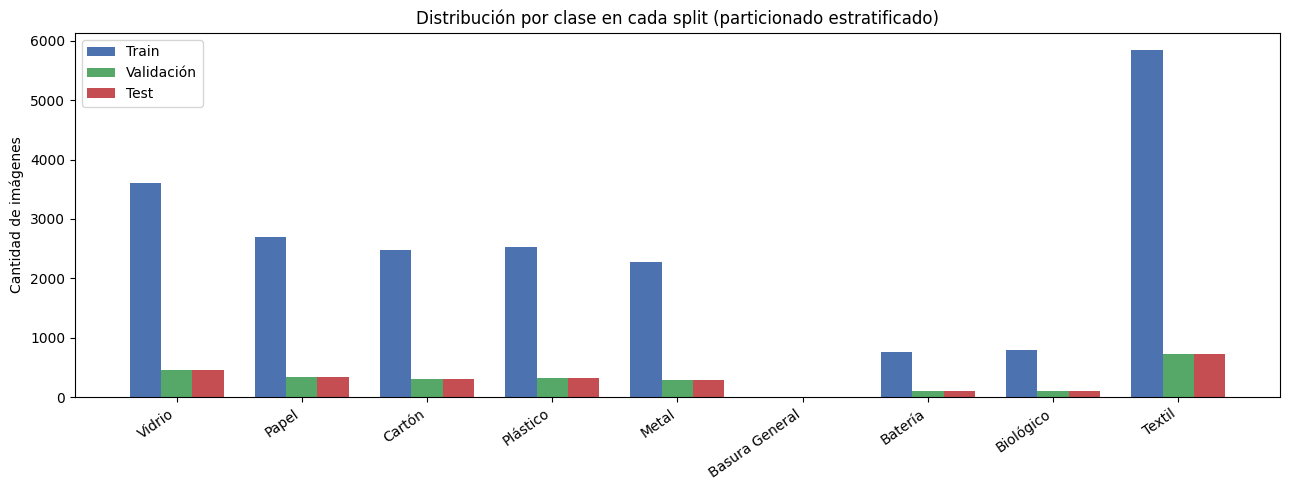

In [12]:
# Visualización de la estratificación
x         = np.arange(len(TARGET_CLASSES))
width     = 0.25
class_labels = [IDX_TO_CLASS[i] for i in range(len(TARGET_CLASSES))]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, df_splits["Train"],      width, label="Train",      color="#4C72B0")
ax.bar(x,         df_splits["Validación"], width, label="Validación", color="#55A868")
ax.bar(x + width, df_splits["Test"],       width, label="Test",       color="#C44E52")

ax.set_xticks(x)
ax.set_xticklabels(class_labels, rotation=35, ha="right")
ax.set_ylabel("Cantidad de imágenes")
ax.set_title("Distribución por clase en cada split (particionado estratificado)")
ax.legend()
plt.tight_layout()
plt.show()

---
## c) Segmentación Semántica con grabCut

Antes del preprocesamiento de clasificación, se aplica segmentación semántica usando `grabCut`. El objetivo es enmascarar el fondo y retener únicamente el objeto principal, reduciendo el ruido visual que podría confundir al clasificador.

Funcionamiento:

La imagen se redimensiona a 224×224 y se normaliza con los stats de ImageNet.
`grabCut` predice una máscara por píxel.
Todos los píxeles no asignados a background (clase 0) forman la máscara del objeto.
Los píxeles de fondo se ponen a negro (0).

In [13]:

def image_segmentation(image):

    image = image.resize((224,224))
    image_np = np.array(image)

    mask = np.zeros(image_np.shape[:2], np.uint8)
    bgdModel = np.zeros((1,65),np.float64)
    fgdModel = np.zeros((1,65),np.float64)

    height, width = image_np.shape[:2]

    rect = (
        10,
        10,
        width - 20,
        height - 20
    )

    cv2.grabCut(

        image_np,
        mask,
        rect,
        bgdModel,
        fgdModel,
        5,
        cv2.GC_INIT_WITH_RECT
    )

    mask_binary = np.where((mask == 2) | (mask == 0),0,1).astype("uint8")
    segmented_image = (image_np * mask_binary[:,:,np.newaxis])

    return image_np, mask_binary, segmented_image

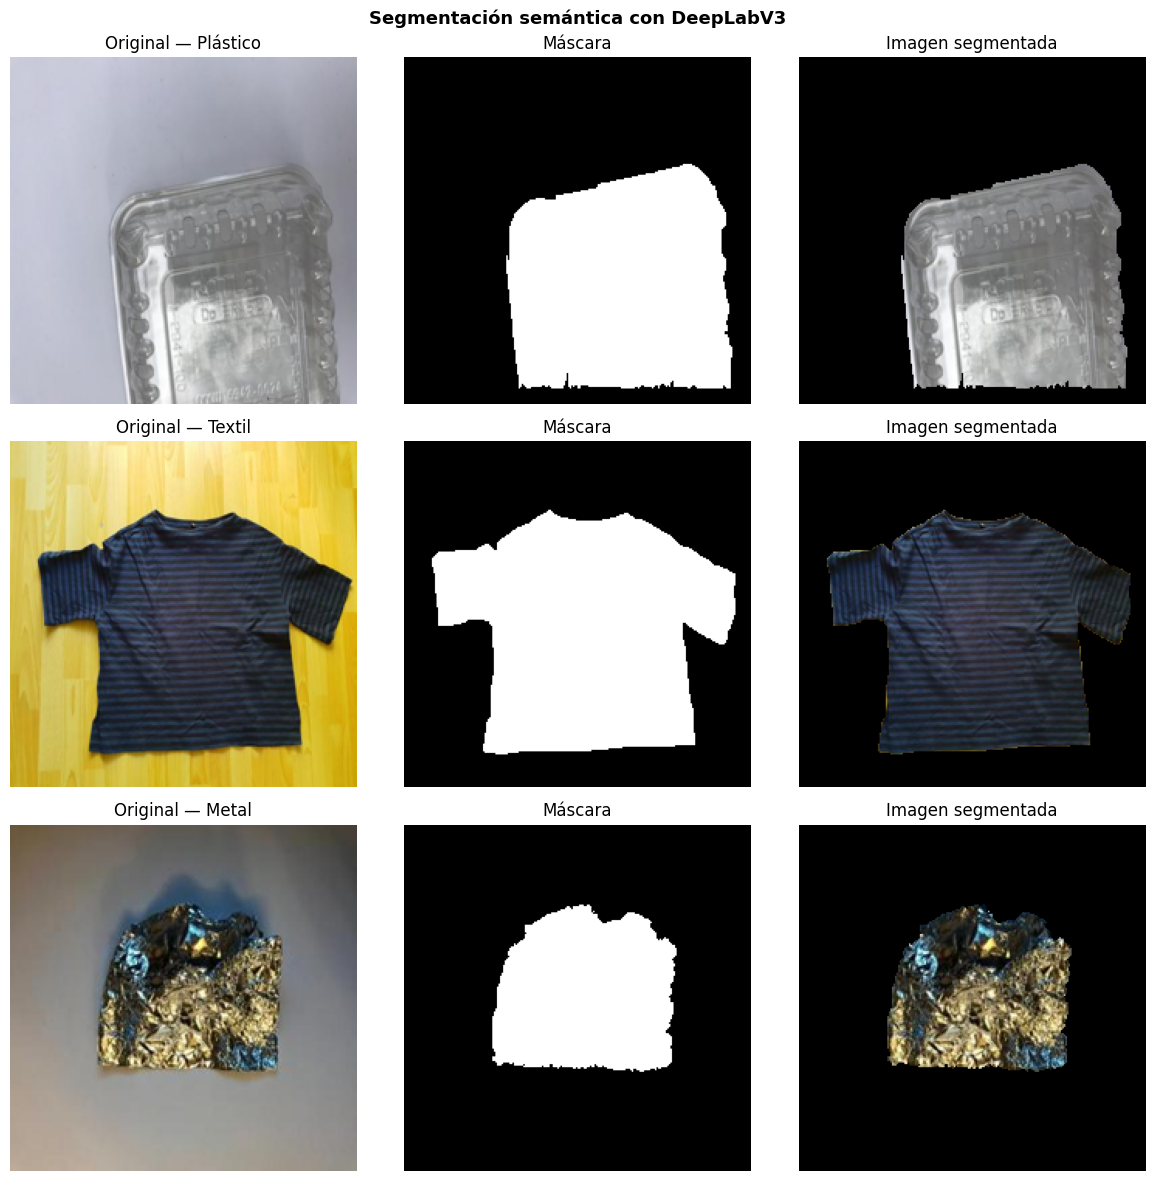

In [17]:
# Demostración visual en 3 imágenes de distintas clases
number_of_images = 3;
demo_indices = random.sample(range(len(full_dataset)), number_of_images)
fig, axes = plt.subplots(len(demo_indices), 3, figsize=(12, 4 * len(demo_indices)))
fig.suptitle("Segmentación semántica con grabCut", fontsize=13, fontweight="bold")

for row, idx in enumerate(demo_indices):
    image, label = full_dataset[idx]
    original, mask, segmented = image_segmentation(image)

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"Original — {IDX_TO_CLASS[label]}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Máscara")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(segmented)
    axes[row, 2].set_title("Imagen segmentada")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

---
## c) Preprocesamiento

Se usan los parámetros estándar de ImageNet (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`) ya que el clasificador posterior utilizará un modelo preentrenado (ResNet/EfficientNet).

**Pipeline para train:**
`Resize(224)` → *augmentations* → `ToTensor` → `Normalize`

**Pipeline para validación/test:**
`Resize(224)` → `ToTensor` → `Normalize`

> Las augmentations **solo** se aplican a train, nunca a validación ni test.

---
## d) Data Augmentation

### Transformaciones aplicadas al set de entrenamiento

| Transformación | Justificación para este problema |
|---|---|
| `RandomHorizontalFlip` | Los residuos no tienen orientación canónica; una botella girada sigue siendo una botella. |
| `RandomRotation(15°)` | Objetos fotografiados en distintos ángulos; pequeñas rotaciones son realistas. |
| `ColorJitter(b=0.2, c=0.2, s=0.2)` | Las condiciones de iluminación varían enormemente (interior/exterior, flash, sombras). |

No se aplica flip vertical ni recortes agresivos porque podrían eliminar partes identificativas del objeto (p.ej., etiquetas en plásticos).

In [18]:
# Transforms para entrenamiento (con data augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transforms para validación y test (sin augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Transforms definidas")
print("   Train:       resize + flip + rotación + color jitter + tensor + norm")
print("   Val / Test:  resize + tensor + norm")

✅ Transforms definidas
   Train:       resize + flip + rotación + color jitter + tensor + norm
   Val / Test:  resize + tensor + norm


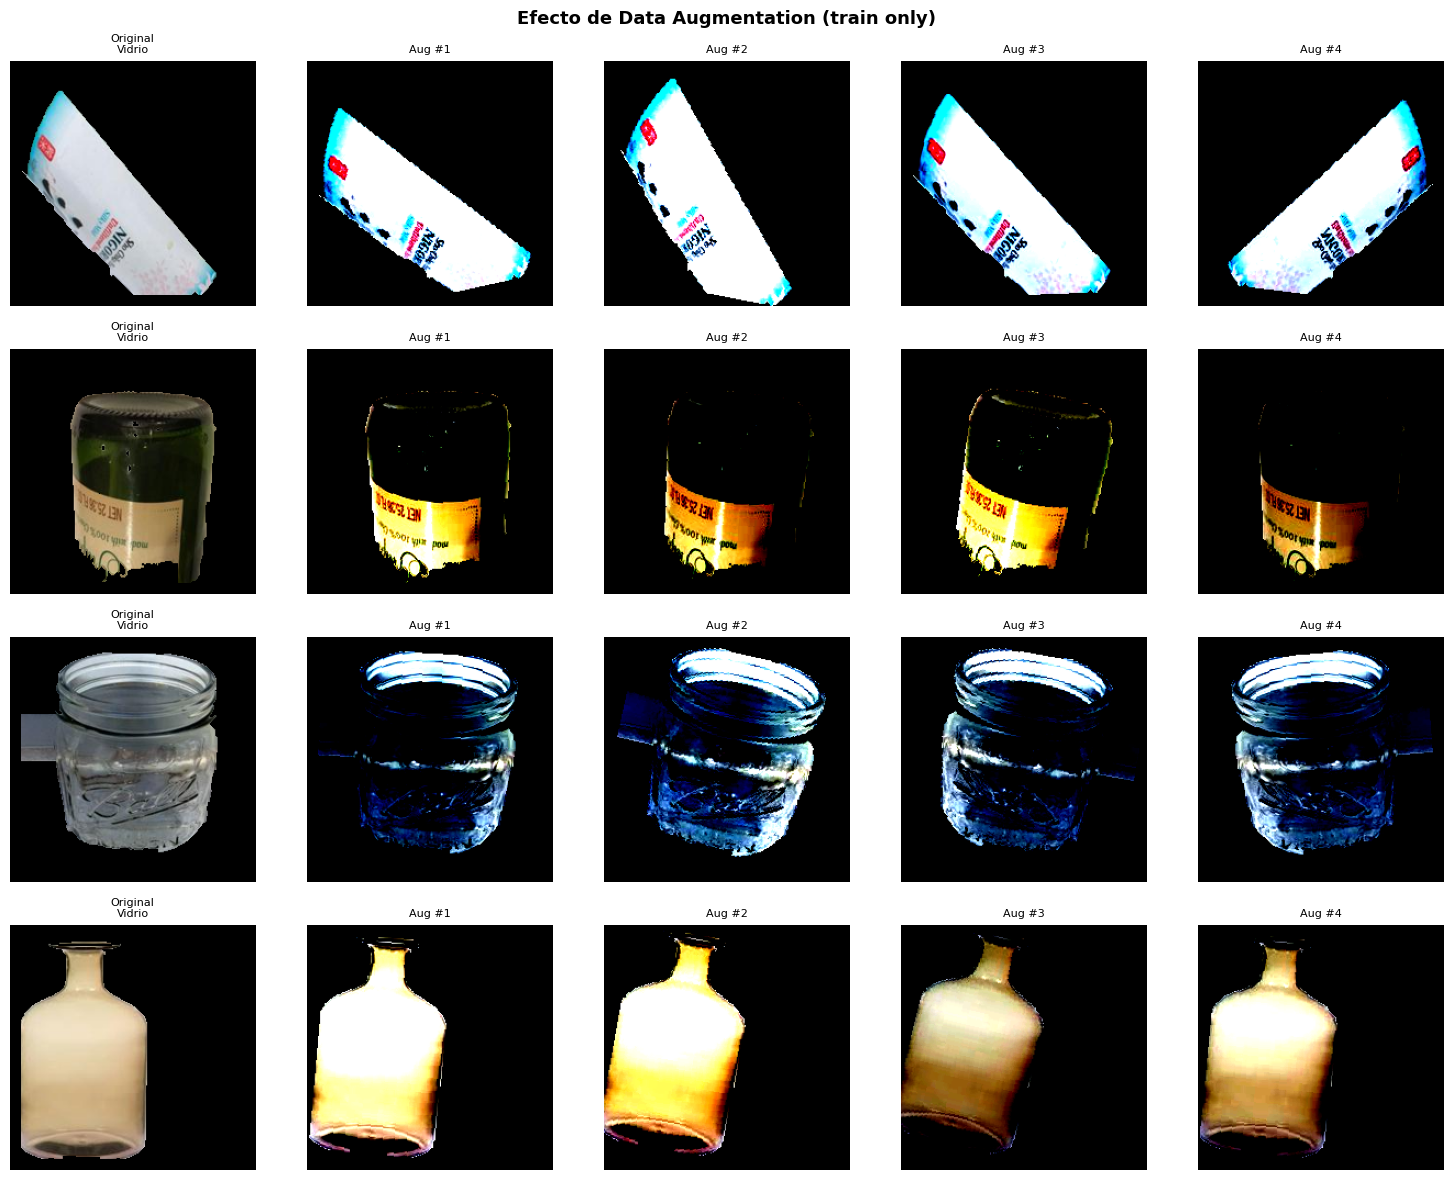

In [19]:
# Visualización del efecto de las augmentations sobre 4 imágenes distintas
sample_indices = [0, 150, 400, 900]
n_versions     = 4   # versiones aumentadas por imagen

fig, axes = plt.subplots(
    len(sample_indices),
    n_versions + 1,
    figsize=(3 * (n_versions + 1), 3 * len(sample_indices))
)
fig.suptitle("Efecto de Data Augmentation (train only)", fontsize=13, fontweight="bold")

for row, idx in enumerate(sample_indices):
    image, label = full_dataset[idx]
    _, _, seg = image_segmentation(image)
    seg_pil = Image.fromarray(seg)

    # Columna 0: original segmentada
    axes[row, 0].imshow(seg)
    axes[row, 0].set_title(f"Original\n{IDX_TO_CLASS[label]}", fontsize=8)
    axes[row, 0].axis("off")

    # Columnas 1..n_versions: versiones aumentadas
    for col in range(1, n_versions + 1):
        aug_tensor = train_transforms(seg_pil)
        aug_np     = aug_tensor.permute(1, 2, 0).numpy()
        aug_np     = np.clip(aug_np, 0, 1)
        axes[row, col].imshow(aug_np)
        axes[row, col].set_title(f"Aug #{col}", fontsize=8)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

---
## Dataset PyTorch Final (`ResiduosDataset`)

Se implementa `ResiduosDataset`, que hereda de `torch.utils.data.Dataset` y encapsula:
1. Acceso a las imágenes del dataset unificado mediante índices del split.
2. Aplicación de segmentación semántica en `__getitem__`.
3. Aplicación de la transform correspondiente (train vs. val/test).

In [23]:
class ResiduosDataset(Dataset):
    """
    Dataset final para clasificación de residuos.
    Aplica segmentación semántica y las transforms del split correspondiente.

    Args:
        base_dataset: instancia de UnifiedGarbageDataset.
        indices:      lista de índices del split (train/val/test).
        transform:    torchvision.transforms.Compose a aplicar.
    """

    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indexes      = indices
        self.transform    = transform

    def __len__(self):
        return len(self.indexes)

    def __getitem__(self, idx):
        real_idx = self.indexes[idx]
        image, label = self.base_dataset[real_idx]

        # Segmentación: aislamos el objeto del fondo
        _, _, segmented_image = image_segmentation(image)
        segmented_pil = Image.fromarray(segmented_image)

        # Preprocesamiento + augmentations (si aplica)
        if self.transform:
            segmented_pil = self.transform(segmented_pil)

        return segmented_pil, label


train_dataset = ResiduosDataset(full_dataset, train_idx, transform=train_transforms)
val_dataset   = ResiduosDataset(full_dataset, val_idx,   transform=val_test_transforms)
test_dataset  = ResiduosDataset(full_dataset, test_idx,  transform=val_test_transforms)

print(f"✅ Datasets creados:")
print(f"   Train:      {len(train_dataset)} muestras")
print(f"   Validación: {len(val_dataset)}  muestras")
print(f"   Test:       {len(test_dataset)}  muestras")

✅ Datasets creados:
   Train:      20975 muestras
   Validación: 2622  muestras
   Test:       2622  muestras


---
## DataLoaders

| Parámetro | Valor | Razón |
|---|---|---|
| `batch_size` | 32 | Tamaño estándar; balanceo entre velocidad de entrenamiento y uso de VRAM. |
| `shuffle=True` | train | Evita que el modelo vea siempre las mismas clases en el mismo orden por epoch. |
| `shuffle=False` | val/test | Las métricas deben ser deterministas entre evaluaciones. |
| `drop_last=True` | train | Evita batches incompletos que podrían distorsionar BatchNorm. |

In [24]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("✅ DataLoaders creados")
print(f"   Batches en train:      {len(train_loader)}")
print(f"   Batches en validación: {len(val_loader)}")
print(f"   Batches en test:       {len(test_loader)}")

✅ DataLoaders creados
   Batches en train:      655
   Batches en validación: 82
   Batches en test:       82


---
## e) Verificación Final del Pipeline

Se extrae un batch del DataLoader de train para confirmar:
- Dimensiones correctas del tensor `(batch_size, C, H, W)`.
- Rango de valores tras la normalización (valores negativos/positivos, no [0,1]).
- Correspondencia correcta entre imágenes y etiquetas al desnormalizar.

In [25]:
def desnormalize(img_tensor):
    """Desnormaliza un tensor (C,H,W) con stats de ImageNet para visualización."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = img_tensor.numpy().transpose((1, 2, 0))
    img  = std * img + mean
    return np.clip(img, 0, 1)

In [26]:
images_batch, labels_batch = next(iter(train_loader))

print("=== Verificación del batch ===")
print(f"Forma del tensor:  {images_batch.shape}")
print(f"  batch_size={images_batch.shape[0]}, canales={images_batch.shape[1]}, "
      f"alto={images_batch.shape[2]}, ancho={images_batch.shape[3]}")
print(f"Tipo de datos:     {images_batch.dtype}")
print(f"Rango (tras norm): [{images_batch.min():.3f}, {images_batch.max():.3f}]")
print(f"Etiquetas batch:   {labels_batch[:8].tolist()}")

=== Verificación del batch ===
Forma del tensor:  torch.Size([32, 3, 224, 224])
  batch_size=32, canales=3, alto=224, ancho=224
Tipo de datos:     torch.float32
Rango (tras norm): [-2.118, 2.640]
Etiquetas batch:   [8, 1, 4, 8, 1, 7, 1, 8]


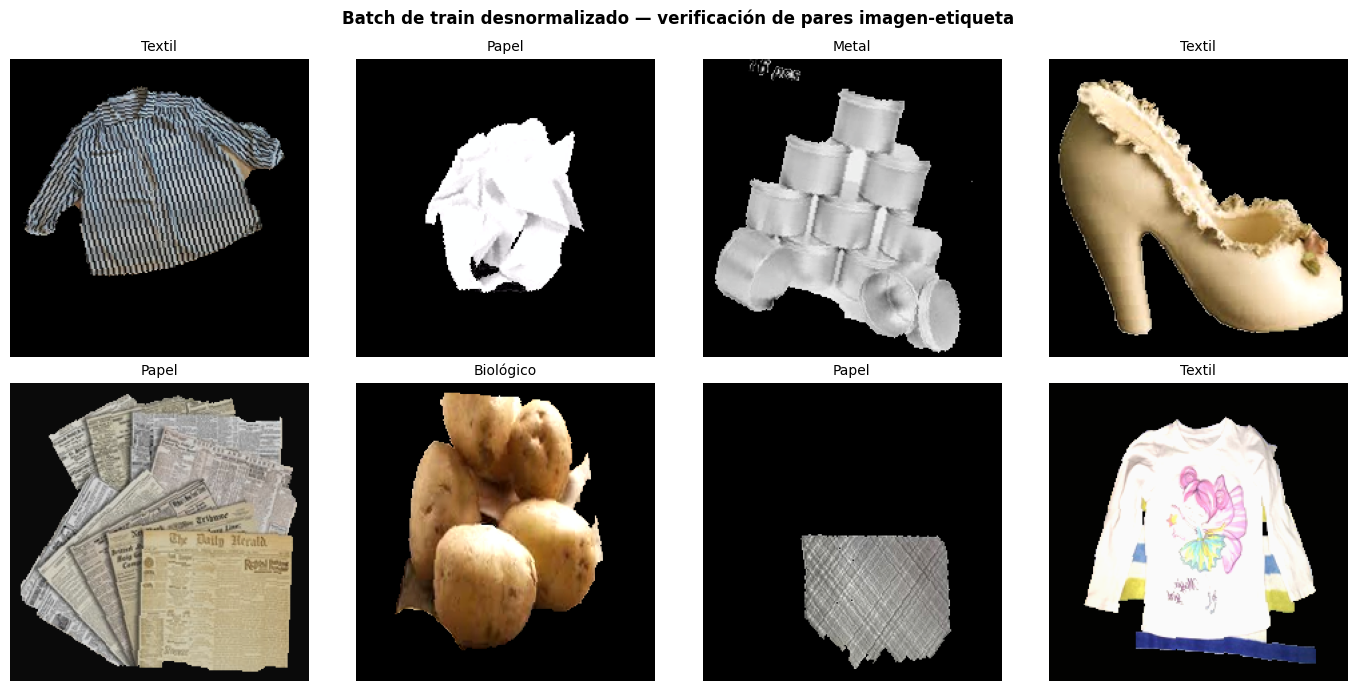


✅ Pipeline completo y verificado.
   Los pares imagen-etiqueta son correctos.
   El notebook está listo para la etapa de fine-tuning.


In [27]:
# Visualización de 8 imágenes del batch con sus etiquetas (desnormalizadas)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle(
    "Batch de train desnormalizado — verificación de pares imagen-etiqueta",
    fontsize=12, fontweight="bold"
)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(desnormalize(images_batch[i]))
    ax.set_title(IDX_TO_CLASS[labels_batch[i].item()], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("\n✅ Pipeline completo y verificado.")
print("   Los pares imagen-etiqueta son correctos.")
print("   El notebook está listo para la etapa de fine-tuning.")